In [1]:
!pip install -q langchain langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 1.8 MB/s eta 0:00:00


In [2]:
import os
from google.colab import userdata

# Safely load the API key from Colab Secrets
os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')

In [7]:
import google.generativeai as genai
import os

# Configure the library with your API key
genai.configure(api_key=os.environ["GOOGLE_API_KEY"])

# Loop through and print only the models that support text generation
print("✅ YOU HAVE ACCESS TO THESE MODELS:")
for m in genai.list_models():
  if 'generateContent' in m.supported_generation_methods:
    print(m.name)

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


✅ YOU HAVE ACCESS TO THESE MODELS:
models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-2.5-flash-lite-preview-09-2025
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-robotics-er-1.5-preview
models/gemini-2.5-computer-use-preview-10-2025
model

🚀 Starting Data Pipeline...

⚙️ Running filter_data on housing.csv...
✅ Filtered data saved to: filtered_data.csv

📊 Running create_graph using data from filtered_data.csv...


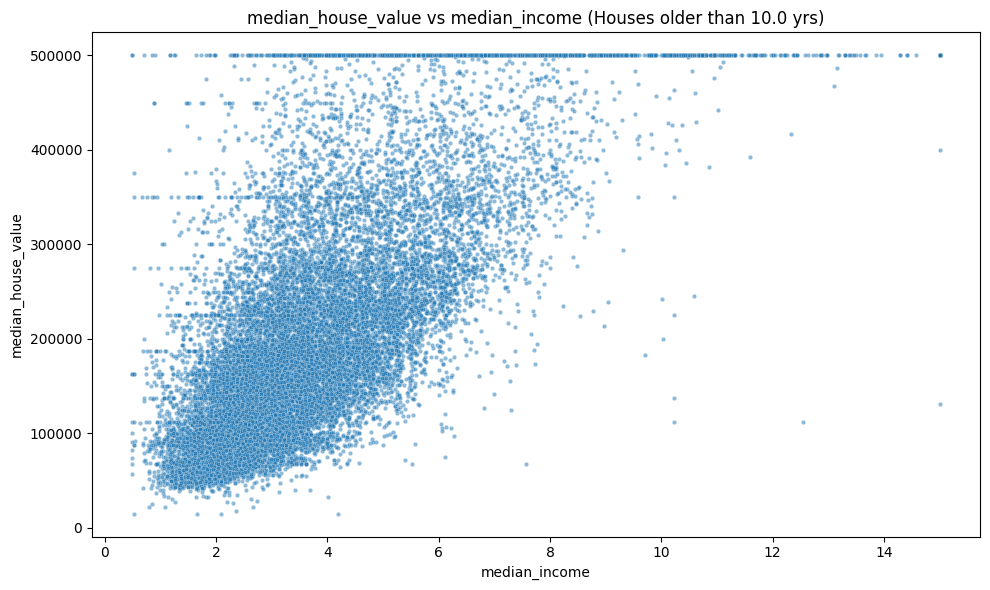

✅ Graph created and saved to: output_graph.png

🧠 Running explain_graph...

✅ Graph Explanation:

Based on the provided statistics, here's an insightful explanation of the relationship between median income and median house values in California:

*   **Positive Relationship:** There is a clear positive relationship: as median income increases, median house values generally rise. The wide range in both variables (income from ~$5,000 to ~$150,000; house values from ~$15,000 to ~$500,000) supports this fundamental economic principle.
*   **Skewed Distributions:** Both distributions are positively skewed, though more pronounced for house values. The mean median house value (\$207,398) is significantly higher than its median (\$180,700), indicating a tail of more expensive properties. Median income also shows a slight positive skew (mean \$38,144 vs. median \$34,764).
*   **Significant Variability:** Both income and house values exhibit considerable variability, with standard deviations rep

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from langchain_core.tools import tool
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
import os

# Initialize the LLM (Ensure you have set your API key in Colab Secrets!)
# Initialize the LLM
# Initialize the LLM
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

@tool
def filter_data(input_csv: str, target_column: str, threshold: float, output_csv: str = "filtered_data.csv") -> str:
    """Reads a CSV, filters data where target_column > threshold, and saves to a new CSV."""
    print(f"⚙️ Running filter_data on {input_csv}...")
    df = pd.read_csv(input_csv)
    filtered_df = df[df[target_column] > threshold]
    filtered_df.to_csv(output_csv, index=False)
    return output_csv

@tool
def create_graph(data_path: str, x_col: str, y_col: str, title: str, output_image: str = "output_graph.png") -> str:
    """Reads filtered data, creates a scatter plot, and saves the graph as an image."""
    print(f"📊 Running create_graph using data from {data_path}...")
    df = pd.read_csv(data_path)

    plt.figure(figsize=(10, 6))
    # For this dataset, a smaller point size (s=10) looks better because there are 20,000+ rows!
    sns.scatterplot(data=df, x=x_col, y=y_col, alpha=0.5, s=10)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(output_image)

    # Display the graph directly in the Colab notebook output
    plt.show()
    plt.close()

    stats_summary = df[[x_col, y_col]].describe().to_dict()
    return f"{output_image}|{stats_summary}"

@tool
def explain_graph(graph_info: str) -> str:
    """Uses a multimodal LLM to explain the graph's statistical data in bullet points."""
    print("🧠 Running explain_graph...\n")
    image_path, stats_summary = graph_info.split("|")

    prompt = f"""
    You are an expert real estate data analyst. I have generated a scatter plot of California Housing Data.
    Here is the statistical summary of the plotted data: {stats_summary}.

    Based on these statistics, provide a concise, insightful explanation of the relationship
    between income and house values in 3-4 bullet points. Focus on trends, averages, and potential outliers.
    """

    response = llm.invoke([HumanMessage(content=prompt)])
    return response.content

def run_data_pipeline(dataset_path: str, column_to_filter: str, filter_limit: float, x_axis: str, y_axis: str):
    print("🚀 Starting Data Pipeline...\n")
    try:
        filtered_file_path = filter_data.invoke({
            "input_csv": dataset_path, "target_column": column_to_filter, "threshold": filter_limit
        })
        print(f"✅ Filtered data saved to: {filtered_file_path}\n")

        graph_output_info = create_graph.invoke({
            "data_path": filtered_file_path, "x_col": x_axis, "y_col": y_axis,
            "title": f"{y_axis} vs {x_axis} (Houses older than {filter_limit} yrs)"
        })
        print(f"✅ Graph created and saved to: {graph_output_info.split('|')[0]}\n")

        explanation = explain_graph.invoke({"graph_info": graph_output_info})
        print("✅ Graph Explanation:\n")
        print(explanation)

    except Exception as e:
        print(f"❌ Pipeline failed: {e}")

# =====================================================================
# VARIABLES FILLED FOR THE CALIFORNIA HOUSING DATASET
# =====================================================================
if __name__ == "__main__":
    run_data_pipeline(
        dataset_path="housing.csv",
        column_to_filter="housing_median_age", # Filters based on the age of the house
        filter_limit=10.0,                     # Keeps houses older than 10 years
        x_axis="median_income",                # Plots median income on the X-axis
        y_axis="median_house_value"            # Plots house value on the Y-axis
    )